In [ ]:
######写一个程序将所有的cr进行修正，在原来基础上添加新的cr_decay

In [1]:
# ===== 标准库 =====
import os
import sys
import math
import pickle
import itertools
# ===== 科学计算 / 数据处理 =====
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import gaussian_kde
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter1d
# ===== 绘图相关 =====
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import font_manager, rcParams
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import matplotlib.image as mpimg
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# ===== 机器学习 / 聚类 =====
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram, cut_tree
import seaborn as sns
# ===== 空间统计 / 空间权重 =====
from libpysal import weights
from libpysal.weights import util, WSP
from esda import Moran_Local
from matplotlib.lines import Line2D

/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/libpysal/weights/util.py:23: UserWarning: geopandas not available. Some functionality will be disabled.
  warn("geopandas not available. Some functionality will be disabled.")
/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/libpysal/examples/remotes.py:24: UserWarning: Remote data sets not available. Check connection.
  warnings.warn("Remote data sets not available. Check connection.")


In [2]:
# 添加 Trajectron++ 所在路径
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/Data_gen/trajectron')
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/Data_ana')
sys.path.append('/home/wangtao/下载/Trajectron-ped-veh/trajectron')
from analysis import risk_field_properties,risk_field_stats,bivariate_gaussian,gmm_overlap_score,load_pkl_by_timestep,replace_outliers_custom,compute_ttc_x,compute_ttc_y,adjust_ttc,add_tdtc,compute_acceleration,heading_rate,compute_act_row,conflict_score_from_mean_intersection

plt.rcParams.update({ 
    'font.family' : 'Liberation Serif',
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'serif',
    # 隐藏上边框和刻度
    'axes.spines.top': True,
    # 保留其他边框和小刻度
    'axes.spines.right': True,
    'axes.spines.bottom': True,
    'axes.spines.left': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    # 刻度朝内
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    # 右侧和上侧的刻度也朝内
    'xtick.top': False,
    'ytick.right': False,
    # 关闭网格
    'axes.grid': False,})

In [3]:
def data_pre(predic, true, history):   
    base_dir =f"/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}"

    with open(os.path.join(base_dir, f"{predic}.pkl"), 'rb') as f:
        pre_full = pickle.load(f)

    with open(os.path.join(base_dir, f"{true}.pkl"), 'rb') as f:
        tru = pickle.load(f)

    with open(os.path.join(base_dir, f"{history}.pkl"), 'rb') as f:
        his = pickle.load(f)

    def key_to_str(k):
        # Trajectron Node: 有 type.name 和 id
        if hasattr(k, "type") and hasattr(k, "id") and hasattr(k.type, "name"):
            return f"{k.type.name}/{k.id}"  # id 会自动转成 str
        return str(k)
    pre_full = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in pre_full.items()}
    tru  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in tru.items()}
    his  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in his.items()}
    return pre_full,tru,his

In [4]:
def key_to_str(k):
    # Trajectron Node: 有 type.name 和 id
    if hasattr(k, "type") and hasattr(k, "id") and hasattr(k.type, "name"):
        return f"{k.type.name}/{k.id}"  # id 会自动转成 str
    return str(k)

def print_two_level_keys(pre_full):
    for outer_k, inner_dict in pre_full.items():
        print(str(outer_k))                      # 打印第一层键
        for inner_k in inner_dict.keys():
            print("   →", str(inner_k))         # 打印第二层键，缩进
#print_two_level_keys(pre_full)

def tra_data(time_step,agent_id):
    ts = str(time_step)
    # frame_list=list(pre_full.keys())
    # for node in tru[frame_list[time_step]].keys():
    #     print('e',int(f'{str(node.id )}'.split('/')[-1]))
    #     if node.type == 'PEDESTRIAN' and int(f'{str(node.id )}'.split('/')[-1])==car_id:  # 注意id是字符串
    tru_traj = np.asarray(tru[ts][agent_id])
    his_traj = np.asarray(his[ts][agent_id])
    pre_traj = np.asarray(pre_full[ts][agent_id])
        # break  # 找到就退出
    return tru_traj,his_traj,pre_traj[0]

In [5]:
def gaussian_parameter(time_step, agent_id):

    """
    输入:
        time_step : int
        agent_id  : 'PEDESTRIAN/178' 或 'VEHICLE/178'
    输出:
        mus[x], sigmas[x], log_pis[x], corrs[x]
    """
    # 取 ID 末尾数字
    target_id = agent_id.split('/')[-1]   # '178'
    # 判断行人 / 车辆
    if agent_id.startswith("PEDESTRIAN/"):
        frame_arr = frame_all_ped
        id_arr    = id_all_ped
        mus_arr   = mus_all_ped
        sig_arr   = sigmas_all_ped
        logpi_arr = log_pis_all_ped
        corr_arr  = corrs_all_ped
    elif agent_id.startswith("VEHICLE/"):
        frame_arr = frame_all_car
        id_arr    = id_all_car
        mus_arr   = mus_all_car
        sig_arr   = sigmas_all_car
        logpi_arr = log_pis_all_car
        corr_arr  = corrs_all_car
    else:
        raise ValueError(f"ID 必须以 'PEDESTRIAN/' 或 'VEHICLE/' 开头: {agent_id}")
    # 转 numpy（确保可 where）
    frame_arr = np.asarray(frame_arr)
    id_arr    = np.asarray(id_arr)
    # 找到所有时间步匹配
    idx_ts = np.where(frame_arr == time_step)[0]
    # 匹配对应ID（直接比较字符串）
    matches = [i for i in idx_ts if str(id_arr[i]).split('/')[-1] == target_id]
    if len(matches) == 0:
        raise ValueError(f"time_step={time_step} 下没有找到 {agent_id}")
    if len(matches) > 1:
        raise ValueError(f"time_step={time_step} 下找到多个 {agent_id}，应唯一 → {matches}")
    x = matches[0]
    return mus_arr[x], sig_arr[x], logpi_arr[x], corr_arr[x],_

In [6]:
def angle_between_vectors_safe(v_x1, v_y1, v_x2, v_y2):
    # Calculate the dot product of the two vectors
    dot_product = v_x1 * v_x2 + v_y1 * v_y2
    # Calculate the magnitudes of the individual vectors
    magnitude1 = np.sqrt(v_x1**2 + v_y1**2)
    magnitude2 = np.sqrt(v_x2**2 + v_y2**2)
    # Check if either magnitude is zero (to avoid division by zero)
    if magnitude1 == 0 or magnitude2 == 0:
        return np.namus_all.shapen # Return NaN if one of the vectors is a zero vector
    # Calculate the angle in radians between the two vectors
    angle = np.arccos(dot_product / (magnitude1 * magnitude2))
    # Check for any numerical errors due to floating point precision
    if np.isnan(angle):
        if dot_product == 0:
            return 90 # Orthogonal vectors
        return 0 if dot_product > 0 else 180 # Parallel or opposite vectors
    # Convert the angle from radians to degrees
    angle_degrees = np.degrees(angle)
    return angle_degrees

# Function to calculate the angle between two vectors
def angle(dx1, dy1, dx2, dy2):
    angle1 = math.degrees(math.atan2(dy1, dx1))
    angle2 = math.degrees(math.atan2(dy2, dx2))
    included_angle = abs(angle1 - angle2) if angle1 * angle2 >= 0 else abs(angle1) + abs(angle2)
    included_angle = 360 - included_angle if included_angle > 180 else included_angle
    included_angle = 360 - included_angle if dx2 < 0 else included_angle
    return math.radians(included_angle)

def mark_regions_in_radians(angle_rad):
    if 0 <= angle_rad < math.pi / 8:  # 0 - 22.5度
        return 1
    elif math.pi / 8 <= angle_rad < 2 * math.pi / 8:  # 22.5 - 45度
        return 2
    elif 2 * math.pi / 8 <= angle_rad < 3 * math.pi / 8:  # 45 - 67.5度
        return 3
    elif 3 * math.pi / 8 <= angle_rad < 4 * math.pi / 8:  # 67.5 - 90度
        return 4
    elif 4 * math.pi / 8 <= angle_rad < 5 * math.pi / 8:  # 90 - 112.5度
        return 5
    elif 5 * math.pi / 8 <= angle_rad < 6 * math.pi / 8:  # 112.5 - 135度
        return 6
    elif 6 * math.pi / 8 <= angle_rad < 7 * math.pi / 8:  # 135 - 157.5度
        return 7
    elif 7 * math.pi / 8 <= angle_rad < math.pi:  # 157.5 - 180度
        return 8
    elif math.pi <= angle_rad < 9 * math.pi / 8:  # 180 - 202.5度
        return 9
    elif 9 * math.pi / 8 <= angle_rad < 10 * math.pi / 8:  # 202.5 - 225度
        return 10
    elif 10 * math.pi / 8 <= angle_rad < 11 * math.pi / 8:  # 225 - 247.5度
        return 11
    elif 11 * math.pi / 8 <= angle_rad < 12 * math.pi / 8:  # 247.5 - 270度
        return 12
    elif 12 * math.pi / 8 <= angle_rad < 13 * math.pi / 8:  # 270 - 292.5度
        return 13
    elif 13 * math.pi / 8 <= angle_rad < 14 * math.pi / 8:  # 292.5 - 315度
        return 14
    elif 14 * math.pi / 8 <= angle_rad < 15 * math.pi / 8:  # 315 - 337.5度
        return 15
    elif 15 * math.pi / 8 <= angle_rad < 2 * math.pi:  # 337.5 - 360度
        return 16
    else:
        return np.nan  # 如果不在 0 - 2π 范围内，标记为 NaN

In [7]:
def final_prob_from_R(R_values, dt=0.4, t_half=1.0, eps=1e-9):
    """
    R_values: 长度 N=16 的 R(t_i)，每点间隔 dt=0.4s
    dt: 时间间隔（秒），默认 0.4
    t_half: 半衰期 t_{1/2}（秒），默认 3.0
    返回:
        P: 1 - exp(-∫ lambda(t)*gamma(t) dt)
        lam_discounted: 各时刻折扣后的 lambda
        integral: 近似积分值
    """
    R = np.asarray(R_values, dtype=float)

    # 数值安全 & 处理 NaN/Inf
    R = np.nan_to_num(R)              # 老版本兼容：不使用 nan=... 关键字
    R[np.isnan(R)] = 0.0
    R = np.clip(R, 0.0 + eps, 1.0 - eps)

    # λ(t) = R / (1 - R)
    lam = R / (1.0 - R)

    # 时间轴：0, 0.4, 0.8, ...
    t = dt * np.arange(R.size)

    # γ(t) = (0.5)^(t/t_half)
    gamma = 0.5 ** (t / t_half)

    # 折扣后的强度
    lam_discounted = lam* gamma

    # ∫ λ(t)γ(t) dt （梯形法）
    integral = np.trapz(lam_discounted, t)

    # P = 1 - exp(-∫ ...)
    P = 1.0 - np.exp(-integral)
    return P

In [8]:
def two_conflict_risk(t,veh1,veh2):
    new_mus_2611,new_sigmas_2611,new_log_pis_2611,new_corrs_2611,_=gaussian_parameter(t,veh1)##(12, 25, 2)
    new_mus_2590,new_sigmas_2590,new_log_pis_2590,new_corrs_2590,_=gaussian_parameter(t,veh2)
    risk=[]
    for i in range(0,16):
        S = gmm_overlap_score(
                new_mus_2611[i], new_sigmas_2611[i], new_log_pis_2611[i], new_corrs_2611[i],
                new_mus_2590[i], new_sigmas_2590[i], new_log_pis_2590[i], new_corrs_2590[i])
        risk.append(S)
    risk_c=[v * 1**t*0.4 for t, v in enumerate(risk)]
    return final_prob_from_R(risk_c)

In [9]:
def key_to_str(k):
    # Trajectron Node: 有 type.name 和 id
    if hasattr(k, "type") and hasattr(k, "id") and hasattr(k.type, "name"):
        return f"{k.type.name}/{k.id}"  # id 会自动转成 str
    return str(k)


In [10]:
def tra_data(time_step,agent_id):
    ts = str(time_step)
    # frame_list=list(pre_full.keys())
    # for node in tru[frame_list[time_step]].keys():
    #     print('e',int(f'{str(node.id )}'.split('/')[-1]))
    #     if node.type == 'PEDESTRIAN' and int(f'{str(node.id )}'.split('/')[-1])==car_id:  # 注意id是字符串
    tru_traj = np.asarray(tru[ts][agent_id])
    his_traj = np.asarray(his[ts][agent_id])
    pre_traj = np.asarray(pre_full[ts][agent_id])
        # break  # 找到就退出
    return tru_traj,his_traj,pre_traj[0]

In [11]:
def two_conflict_risk_max_min_mean(t,veh1,veh2):
    new_mus_2611,new_sigmas_2611,new_log_pis_2611,new_corrs_2611,_=gaussian_parameter(t,veh1)##(12, 25, 2)
    new_mus_2590,new_sigmas_2590,new_log_pis_2590,new_corrs_2590,_=gaussian_parameter(t,veh2)
    risk=[]
    for i in range(0,16):
        S = gmm_overlap_score(
                new_mus_2611[i], new_sigmas_2611[i], new_log_pis_2611[i], new_corrs_2611[i],
                new_mus_2590[i], new_sigmas_2590[i], new_log_pis_2590[i], new_corrs_2590[i])
        risk.append(S)
    risk_c=[v * 1**t*0.4 for t, v in enumerate(risk)]

    return max(risk_c),min(risk_c),np.mean(risk_c),np.median(risk_c)

In [12]:
location='FC'
base_path = f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}'
base_dir = f"/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}"
first_nums = []   # 存 92
second_nums = []  # 存 610
for fname in os.listdir(base_dir):
    # 只处理以 TJ_pre_full_ 开头的文件
    if not fname.startswith(f"{location}_pre_full_"):
        continue
    # 去掉扩展名，例如 .pkl, .npy 等
    name_no_ext, _ = os.path.splitext(fname)
    # 按 "_" 切分：["TJ", "pre", "full", "92", "610"]
    parts = name_no_ext.split("_")
    if len(parts) < 5:
        # 格式不符合 TJ_pre_full_x_y，跳过
        continue
    try:
        num1 = int(parts[-2])   # 92
        num2 = int(parts[-1])   # 610
    except ValueError:
        # 最后两段不是数字，跳过
        continue
    first_nums.append(num1)
    second_nums.append(num2)
print("第一组数字列表：", first_nums)
print("第二组数字列表：", second_nums)

if location is 'FC':
    del first_nums[15]
    del second_nums[15]

第一组数字列表： [30, 40, 55, 67, 36, 46, 25, 33, 35, 61, 49, 49, 53, 28, 48, 9, 51, 43, 59, 37, 32, 40, 41, 50, 42, 37, 59, 59, 53, 41, 61, 38, 46, 46, 46, 32, 28, 25, 50, 73, 51, 55, 49, 22, 43, 55, 38, 49, 55, 32, 62, 37, 38, 43, 43, 37, 43, 30, 54, 37, 36, 38, 61, 44, 27, 28]
第二组数字列表： [802, 802, 483, 802, 570, 319, 802, 801, 797, 324, 455, 326, 428, 321, 609, 341, 475, 642, 286, 483, 322, 168, 802, 627, 479, 713, 164, 481, 309, 642, 616, 802, 482, 638, 321, 802, 771, 462, 161, 161, 160, 641, 155, 162, 323, 304, 568, 802, 153, 638, 636, 114, 321, 143, 482, 642, 480, 227, 641, 161, 321, 163, 482, 153, 803, 456]


In [13]:
all_dfs_FC = []   # ✅ 用来收集每一段的 dataframe
for data in range(len(first_nums)):

    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_pre_full_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        pre_full = pickle.load(f)
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_tru_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        tru = pickle.load(f)
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_his_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        his = pickle.load(f)

    pre_full = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in pre_full.items()}
    tru  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in tru.items()}
    his  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in his.items()}

    mus_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_mus_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
    sigmas_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
    log_pis_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')).detach().cpu().numpy()[0]  # [1717,12, 25]
    corrs_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
    id_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_id_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')) 
    frame_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_frame_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))

    mus_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_mus_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
    sigmas_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
    log_pis_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()  # [1717,12, 25]
    corrs_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
    id_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_id_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))
    frame_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_frame_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))
   
    result_font=pd.read_csv(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/{location}_data/result_font_{location}_section_{data}.csv')
    result_font['cr_revision'] =result_font.apply(lambda row: two_conflict_risk(int(row['frame']), row['id_car'], row['id_ped']),axis=1)
    #conflict_score_from_mean_intersection(t, veh1, veh2, dt_step=0.4, H=16)

    cols = ['cr_max','cr_min','cr_mean','cr_median']
    result_font[cols] = (
        result_font.apply(lambda row: two_conflict_risk_max_min_mean(
            int(row['frame']), row['id_car'], row['id_ped']), axis=1)
        .apply(pd.Series)
    )##risk_field_stats(gaussian_parameter, timestep, veh_name):
    all_dfs_FC.append(result_font)

# ✅ 6) 合并成一个大的 dataframe
big_df_FC= pd.concat(all_dfs_FC, ignore_index=True, sort=False)


In [14]:
location='TJ'
base_path = f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}'
base_dir = f"/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}"
first_nums = []   # 存 92
second_nums = []  # 存 610
for fname in os.listdir(base_dir):
    # 只处理以 TJ_pre_full_ 开头的文件
    if not fname.startswith(f"{location}_pre_full_"):
        continue
    # 去掉扩展名，例如 .pkl, .npy 等
    name_no_ext, _ = os.path.splitext(fname)
    # 按 "_" 切分：["TJ", "pre", "full", "92", "610"]
    parts = name_no_ext.split("_")
    if len(parts) < 5:
        # 格式不符合 TJ_pre_full_x_y，跳过
        continue
    try:
        num1 = int(parts[-2])   # 92
        num2 = int(parts[-1])   # 610
    except ValueError:
        # 最后两段不是数字，跳过
        continue
    first_nums.append(num1)
    second_nums.append(num2)
print("第一组数字列表：", first_nums)
print("第二组数字列表：", second_nums)

if location is 'FC':
    del first_nums[15]
    del second_nums[15]

第一组数字列表： [48, 62, 77, 64, 74, 81, 67, 47, 57, 57, 55, 80, 65, 67, 55, 46, 60, 68, 67, 57, 76, 33, 72, 63, 63, 28, 67, 69, 56, 65, 59, 77, 79, 77, 72, 63, 54, 54, 58, 69, 72, 62, 61, 69, 76, 48, 70, 66, 54, 66, 72, 63, 71, 71, 68, 67, 61, 76, 73, 70, 68, 56, 64, 54, 63, 44, 45, 81, 81, 47, 81, 69, 59, 92, 75, 37, 58, 74, 26, 58, 64, 70, 72, 54, 82, 27, 60, 68, 70, 62, 78, 80, 73, 55, 92]
第二组数字列表： [1549, 2418, 2462, 3022, 3048, 615, 1830, 1672, 2581, 610, 605, 3002, 3250, 2399, 1813, 1209, 3074, 650, 2889, 516, 1801, 1180, 584, 615, 2600, 472, 3022, 2438, 2787, 2401, 2335, 2345, 2459, 1173, 1830, 1847, 1219, 1799, 587, 2439, 1230, 558, 3049, 1201, 1963, 2440, 1156, 1868, 1209, 600, 2918, 655, 2932, 2460, 1751, 605, 610, 601, 3113, 1845, 2618, 3272, 1734, 1167, 1220, 2229, 1033, 3078, 623, 1115, 2417, 616, 1814, 610, 2999, 944, 1219, 2490, 236, 1231, 2065, 2311, 1829, 578, 1950, 708, 3050, 1245, 1759, 1844, 1230, 3075, 1309, 1199, 1300]


In [15]:
second_nums.index(1950)

84

In [16]:
all_dfs_TJ = []   # ✅ 用来收集每一段的 dataframe
for data in range(len(first_nums)):

    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_pre_full_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        pre_full = pickle.load(f)
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_tru_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        tru = pickle.load(f)
    with open(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/Data_gen/{location}/{location}_his_{first_nums[data]}_{second_nums[data]}.pkl', 'rb') as f:
        his = pickle.load(f)

    pre_full = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in pre_full.items()}
    tru  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in tru.items()}
    his  = {
        key_to_str(outer_k): {key_to_str(inner_k): inner_v for inner_k, inner_v in outer_v.items()}
        for outer_k, outer_v in his.items()}

    mus_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_mus_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
    sigmas_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
    log_pis_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')).detach().cpu().numpy()[0]  # [1717,12, 25]
    corrs_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
    id_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_id_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl')) 
    frame_all_car = load_pkl_by_timestep(os.path.join(base_path, f'{location}_frame_{first_nums[data]}_VEHICLE_{second_nums[data]}.pkl'))

    mus_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_mus_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25, 2]
    sigmas_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_sigmas_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]   # [1717,12, 25, 2]
    log_pis_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_log_pis_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()  # [1717,12, 25]
    corrs_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_corrs_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))[0].detach().cpu().numpy()[0]      # [1717,12, 25]
    id_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_id_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))
    frame_all_ped = load_pkl_by_timestep(os.path.join(base_path, f'{location}_frame_{first_nums[data]}_PEDESTRIAN_{second_nums[data]}.pkl'))

    result_font=pd.read_csv(f'/home/wangtao/下载/Trajectron-ped-veh/Data_ana/{location}_data/result_font_{location}_section_{data}.csv')
    result_font['cr_revision'] =result_font.apply(lambda row: two_conflict_risk(int(row['frame']), row['id_car'], row['id_ped']),axis=1)
    #conflict_score_from_mean_intersection(t, veh1, veh2, dt_step=0.4, H=16)

    cols = ['cr_max','cr_min','cr_mean','cr_median']
    result_font[cols] = (
        result_font.apply(lambda row: two_conflict_risk_max_min_mean(
            int(row['frame']), row['id_car'], row['id_ped']), axis=1)
        .apply(pd.Series)
    )##risk_field_stats(gaussian_parameter, timestep, veh_name):
    all_dfs_TJ.append(result_font)

# ✅ 6) 合并成一个大的 dataframe
big_df_TJ = pd.concat(all_dfs_TJ, ignore_index=True, sort=False)

In [18]:
result_font_TJ = big_df_TJ
result_font_FC = big_df_FC

In [19]:
result_font_TJFC=pd.concat([result_font_TJ,result_font_FC])[::10]

(array([2796.,  203.,   75.,   51.,   23.,   19.,    7.,    4.,    7.,
           9.]),
 array([0.00010009, 0.00383475, 0.00756942, 0.01130408, 0.01503875,
        0.01877341, 0.02250808, 0.02624274, 0.02997741, 0.03371207,
        0.03744673]),
 <BarContainer object of 10 artists>)

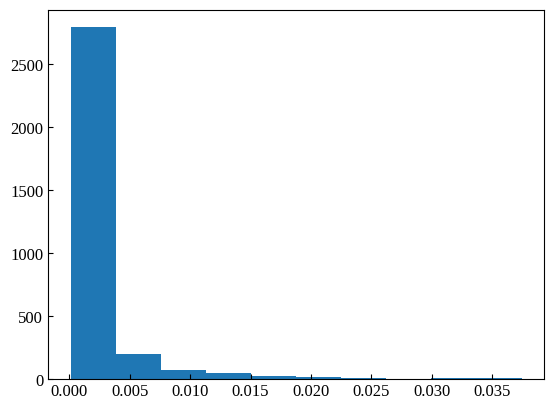

In [20]:
plt.hist(result_font_TJFC[(result_font_TJFC['cr_revision']<0.04)&(result_font_TJFC['cr_revision']>0.0001)]['cr_revision'])

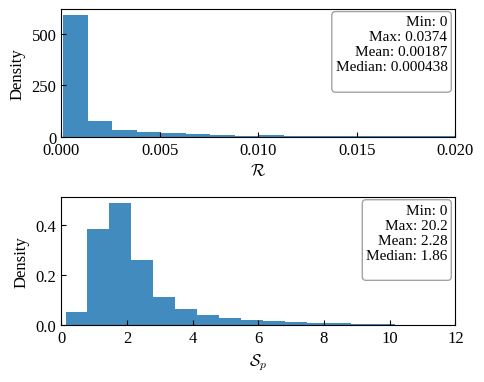

In [21]:
def add_stats_text(ax, data, bins=30, min_fixed0=True, fmt=".3g"):
    data = np.asarray(data, float)
    data = data[np.isfinite(data)]
    if data.size == 0:
        ax.text(0.98, 0.95, "No data", transform=ax.transAxes,
                ha="right", va="top", fontsize=11)
        return

    vmin = 0.0 if min_fixed0 else float(np.min(data))
    vmax = float(np.max(data))
    mean = float(np.mean(data))
    med  = float(np.median(data))

    # 众数：直方图最高bin中心近似
    counts, edges = np.histogram(data, bins=bins)
    idx = int(np.argmax(counts))
    mode = float(0.5 * (edges[idx] + edges[idx+1]))

    txt = (
        f"Min: {format(vmin, fmt)}\n"
        f"Max: {format(vmax, fmt)}\n"
        f"Mean: {format(mean, fmt)}\n"
        f"Median: {format(med, fmt)}\n"
    )

    ax.text(0.98, 0.95, txt, transform=ax.transAxes,
            ha="right", va="top", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9))

# ================== 画图 ==================
fig, axes = plt.subplots(2, 1, figsize=(5,4), sharex=False)

# --- (1) cr_revision（按你给的范围筛选） ---
cr = result_font_TJFC['cr_revision'].replace([np.inf, -np.inf], np.nan).dropna()
cr_sel = cr[(cr < 0.04) & (cr > 0.0001)]

bins1 = 30
axes[0].hist(cr_sel, bins=bins1, density=True, alpha=0.85)
axes[0].set_xlabel(r'$\mathcal{R}$')
axes[0].set_ylabel('Density')
axes[0].set_xlim(0,0.02)
add_stats_text(axes[0], cr_sel.values, bins=bins1, min_fixed0=True, fmt=".3g")

# --- (2) spread ---
sp = result_font_TJFC['spread'].replace([np.inf, -np.inf], np.nan).dropna()

bins2 = 30
axes[1].hist(sp, bins=bins2, density=True, alpha=0.85)
axes[1].set_xlabel(r'$\mathcal{S}_{p}$')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0,12)
add_stats_text(axes[1], sp.values, bins=bins2, min_fixed0=True, fmt=".3g")

plt.tight_layout()

plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/dis.svg', dpi=300, bbox_inches="tight", pad_inches=0.05)

plt.show()

In [22]:
def sci_to_latex_times10(x, digits=2):
    # 处理 0
    if x == 0:
        return "0"
    # 处理 nan/inf
    if not math.isfinite(x):
        return str(x)

    exp = int(math.floor(math.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{digits}f}\times 10^{{{exp}}}"

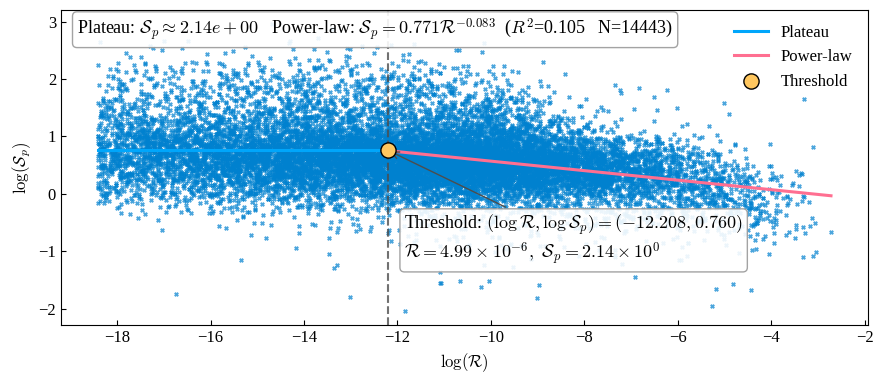

{'break_index': 6090, 'break_lx': -12.207804518282883, 'break_x': 4.9913481303676155e-06, 'plateau_logy': 0.7595223514762571, 'plateau_y': 2.137255119899754, 'right_intercept_loga': -0.25950970645832433, 'right_A': 0.7714297201072131, 'right_slope_b': -0.08290138905402551, 'r2_piece_log': 0.10467995805985364}


In [23]:
def piecewise_plateau_powerlaw_fit(x0, y0,
                                   x_min=1e-7,
                                   y_quantile_clip=(1e-5, 1-1e-5),
                                   min_points=50):
    # ===== 1) 基础过滤：finite + >0 =====
    x0 = np.asarray(x0, float)
    y0 = np.asarray(y0, float)
    m = np.isfinite(x0) & np.isfinite(y0) & (x0 > 0) & (y0 > 0)
    x, y = x0[m], y0[m]

    # ===== 2) 删掉很小的 x（R≈0）=====
    if x_min is not None:
        m2 = x >= x_min
        x, y = x[m2], y[m2]

    # ===== 3) 裁剪 y 极端值 =====
    if y_quantile_clip is not None:
        q_lo, q_hi = y_quantile_clip
        y_lo, y_hi = np.quantile(y, q_lo), np.quantile(y, q_hi)
        m3 = (y >= y_lo) & (y <= y_hi)
        x, y = x[m3], y[m3]

    # ===== 4) log-log =====
    lx, ly = np.log(x), np.log(y)

    # 按 lx 排序，便于找断点
    order = np.argsort(lx)
    lx, ly = lx[order], ly[order]

    n = len(lx)
    if n < 2 * min_points + 5:
        raise ValueError(f"有效样本太少：n={n}，请降低 min_points 或放宽过滤条件。")

    # ===== 5) 遍历断点：左边常数，右边线性 =====
    best = None
    for k in range(min_points, n - min_points):
        # 左段：常数 c = mean(ly_left)
        c = np.mean(ly[:k])
        resid_left = ly[:k] - c
        sse_left = np.sum(resid_left**2)

        # 右段：线性 ly = a + b*lx
        b, a = np.polyfit(lx[k:], ly[k:], 1)  # 注意：polyfit 返回 [slope, intercept]
        ly_hat_right = a + b * lx[k:]
        resid_right = ly[k:] - ly_hat_right
        sse_right = np.sum(resid_right**2)

        sse = sse_left + sse_right
        if (best is None) or (sse < best["sse"]):
            best = dict(k=k, c=c, a=a, b=b, sse=sse)

    # ===== 6) 计算整体 R²（在 log 空间）=====
    k = best["k"]
    c, a, b = best["c"], best["a"], best["b"]

    ly_hat = np.empty_like(ly)
    ly_hat[:k] = c
    ly_hat[k:] = a + b * lx[k:]

    ss_res = np.sum((ly - ly_hat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2_piece = 1.0 - ss_res / (ss_tot + 1e-30)

    # 右段对应原空间幂律参数： y = A * x^b，A = exp(a)
    A = np.exp(a)
    x_break = np.exp(lx[k])  # 断点对应的 x（原空间）
    y_plateau = np.exp(c)    # 平台 y

    # ===== 7) 画图 =====
# ===== 7) 画图 =====
    fig, ax = plt.subplots(figsize=(9,4))
    ax.scatter(lx, ly, s=6, alpha=0.7, c="#0081cf", marker='x')

    # 左段平台线
    ax.plot([lx.min(), lx[k]], [c, c], lw=2.2, c="#00a6fb", label="Plateau")

    # 右段线性下降
    lx_line = np.linspace(lx[k], lx.max(), 200)
    ly_line = a + b * lx_line
    ax.plot(lx_line, ly_line, lw=2.2, c="#ff6f91", label="Power-law")

    # 断点竖线
    ax.axvline(lx[k], ls="--", lw=1.5, c="0.3", alpha=0.8)

    # ✅ 断点散点（标记出来）
    xk, yk = lx[k], c  # 平台段在断点处的 y 值就是 c（你也可改成 ly[k]）
    ax.scatter([xk], [yk], s=120, marker='o', edgecolors="k",
               linewidths=1.0, color="#ffc75f", zorder=10, label="Threshold")

    # ✅ 标注断点坐标（log 空间 + 原空间）
    x_break = np.exp(xk)
    y_break = np.exp(yk)
    txt = (rf"Threshold: $(\log\mathcal{{R}},\log\mathcal{{S}}_p)=({xk:.3f},{yk:.3f})$" "\n"
           rf"$\mathcal{{R}}={sci_to_latex_times10(x_break,2)},\ \mathcal{{S}}_p={sci_to_latex_times10(y_break,2)}$")

    ax.annotate(
        txt,
        xy=(xk, yk),
        xytext=(12, -45),             # 文字偏移（像素）
        textcoords="offset points",
        ha="left", va="top",
        fontsize=13,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color="0.3", lw=1.0))

    ax.set_xlabel(r"$\log(\mathcal{R})$")
    ax.set_ylabel(r"$\log(\mathcal{S}_{p})$")

    info = (
        rf"Plateau: $\mathcal{{S}}_p\approx{np.exp(c):.2e}$   "
        rf"Power-law: $\mathcal{{S}}_p={A:.3f}\mathcal{{R}}^{{{b:.3f}}}$  "
        rf"($R^2$={r2_piece:.3f}   N={n})")
    ax.text(
        0.02, 0.98, info, transform=ax.transAxes,
        ha="left", va="top", fontsize=13,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9))

    ax.legend(frameon=False, loc="best")
    fig.tight_layout()
    plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/law.svg', dpi=300, bbox_inches="tight", pad_inches=0.05)
    plt.show()

    return {
        "break_index": k,
        "break_lx": lx[k],
        "break_x": x_break,
        "plateau_logy": c,
        "plateau_y": y_plateau,
        "right_intercept_loga": a,
        "right_A": A,
        "right_slope_b": b,
        "r2_piece_log": r2_piece}

# ===== 用法（你现在的 TJFC）=====
x0 = result_font_TJFC['cr_revision'].to_numpy(dtype=float)
y0 = result_font_TJFC['spread'].to_numpy(dtype=float)

res = piecewise_plateau_powerlaw_fit(
    x0, y0,
    x_min=1e-8,                 # 你现在用的阈值
    y_quantile_clip=(1e-5, 1-1e-5),
    min_points=80)

print(res)

In [24]:
def to_times10(x, digits=2):
    if x == 0:
        return "0"
    if not math.isfinite(float(x)):
        return str(x)
    exp = int(math.floor(math.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{digits}f}\times10^{{{exp}}}"

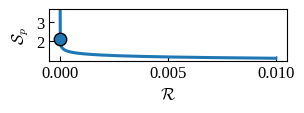

In [25]:
# 幂律曲线参数
A = 7.71e-01
b = -0.083

# 要标注的点
R0 = 4.99e-06
S0 = 2.14e+00

# 曲线范围（包含该点）
R_min, R_max = 1e-8, 1e-2
R = np.logspace(np.log10(R_min), np.log10(R_max), 400)
Sp = A * (R ** b)

plt.figure(figsize=(3.2,1.3))

# 曲线
plt.plot(R, Sp, linewidth=2.2, label = rf"$\mathcal{{S}}_p={A:.3f}\mathcal{{R}}^{{{b:.3f}}}$ ")

# 点
plt.scatter([R0], [S0], s=80, marker='o', edgecolors='k', linewidths=1.0, zorder=5, label="Threshold")

# 标注
# plt.annotate(
#     rf"$\mathcal{{R}}={to_times10(R0,2)},\ \mathcal{{S}}_p={to_times10(S0,2)}$",
#     xy=(R0, S0),
#     xytext=(10, 10),
#     textcoords="offset points",
#     ha="left", va="bottom",
#     fontsize=10,
#     bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.6", alpha=0.9),
#     arrowprops=dict(arrowstyle="->", color="0.3", lw=1.0)
# )

# log-log 更直观
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"$\mathcal{R}$")
plt.ylabel(r"$\mathcal{S}_{p}$")
# plt.grid(alpha=0.25, which="both")
# plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/law1.svg', dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

In [26]:
# === 公共函数：IQR 去异常 ===
def remove_outliers_iqr(df, q_low=0.01, q_high=0.99, k=1.0):
    num_cols = df.select_dtypes(include=[np.number]).columns
    Q1 = df[num_cols].quantile(q_low)
    Q3 = df[num_cols].quantile(q_high)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    mask = pd.DataFrame(True, index=df.index, columns=num_cols)
    for c in num_cols:
        mask[c] = df[c].between(lower[c], upper[c])
    keep = mask.all(axis=1)
    return df[keep]

# === 公共函数：对一个 result_font 做清洗 + 聚类，返回带 cluster 的 DataFrame ===
def preprocess_and_cluster(result_font):

    # 1) 把 angle_radians 映射到 [0, π]
    mask = result_font['angle_radians'] > np.pi
    result_font.loc[mask, 'angle_radians'] = 2*np.pi - result_font.loc[mask, 'angle_radians']

    # 2) 方向向量夹角（车和人）
    dot = result_font['Δx_car'] * result_font['Δx_ped'] + result_font['Δy_car'] * result_font['Δy_ped']
    norm_car = np.sqrt(result_font['Δx_car']**2 + result_font['Δy_car']**2)
    norm_ped = np.sqrt(result_font['Δx_ped']**2 + result_font['Δy_ped']**2)
    denom = norm_car * norm_ped
    cos_theta = dot / denom
    cos_theta = cos_theta.clip(-1, 1)
    result_font['angle_radians_dir'] = np.arccos(cos_theta)
    result_font['angle_degrees_dir'] = np.degrees(result_font['angle_radians_dir'])

    # 3) 选取特征
    COLS = ['cr_revision', 'cr_max', 'cr_mean', 'spread']
    cleaned_data = result_font[COLS].copy()[::3]  # 下采样
    cleaned_data = cleaned_data.dropna()

    dfX = cleaned_data.replace([np.inf, -np.inf], np.nan)
    dfX = dfX.fillna(dfX.median(numeric_only=True))

    # 4) IQR 去异常
    without_outliers = remove_outliers_iqr(dfX, q_low=0.01, q_high=0.99, k=1.0)

    # 5) 标准化
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(without_outliers[COLS])

    # 6) 层次聚类
    Z_complete = linkage(scaled_data, method="complete", metric="euclidean")
    labels = fcluster(Z_complete, t=3, criterion='maxclust')  # 1..3

    # 7) 把 cluster 标签加回原 DataFrame
    cluster_s = pd.Series(labels, index=without_outliers.index, name='cluster')
    result_with_cluster = result_font.join(cluster_s)
    result_with_cluster['cluster'] = result_with_cluster['cluster'].fillna(0).astype(int)

    return result_with_cluster

In [27]:
def add_signed_acceleration(
    df: pd.DataFrame,
    vx_col: str = "v_x_car",
    vy_col: str = "v_y_car",
    ax_col: str = "a_x_car",
    ay_col: str = "a_y_car",
    out_col: str = "a_signed_car",
    v_min: float = 0.2,     # 低速阈值：低于该速度时符号不稳定，默认置0
    thr: float = 0.05,      # 去噪阈值：|a|<thr 置0
    eps: float = 1e-6,
) -> pd.DataFrame:
    """
    输入: df (含 vx, vy, ax, ay 列)
    输出: 返回一个新 df，新增 out_col 为“带符号加速度”：
         >0 加速，<0 减速，=0 匀速/低速/噪声
    """
    out = df.copy()

    vx = out[vx_col].astype(float).to_numpy()
    vy = out[vy_col].astype(float).to_numpy()
    ax = out[ax_col].astype(float).to_numpy()
    ay = out[ay_col].astype(float).to_numpy()

    speed = np.sqrt(vx**2 + vy**2)
    a_signed = (vx * ax + vy * ay) / np.maximum(speed, eps)  # 切向加速度

    # 低速时方向不稳定：置0（也可改成 np.nan）
    a_signed = np.where(speed < v_min, 0.0, a_signed)

    # 去噪：非常小的加速度视为0
    a_signed = np.where(np.abs(a_signed) < thr, 0.0, a_signed)

    out[out_col] = a_signed
    return out

In [28]:
result_font_TJ_1 = add_signed_acceleration(result_font_TJ)

In [29]:
# === 分别做清洗 + 聚类 ===
result_TJ = preprocess_and_cluster(result_font_TJ_1)
result_FC = preprocess_and_cluster(result_font_FC)

In [30]:
def split_clusters(df):
    c1 = df[df['cluster'] == 1].copy()
    c2 = df[df['cluster'] == 2].copy()
    c3 = df[df['cluster'] == 3].copy()
    return c1, c2, c3


# ===== 1) 先 split =====
cluster1_TJ, cluster2_TJ, cluster3_TJ = split_clusters(result_TJ)
cluster1_FC, cluster2_FC, cluster3_FC = split_clusters(result_FC)

# ===== 2) 用 cr_revision 均值自动决定 (Cluster 1/2/3) 的语义标签 =====
def build_cluster_order_and_labels(c1, c2, c3):
    groups = [c1, c2, c3]

    means = []
    for g in groups:
        s = pd.to_numeric(g["cr_revision"], errors="coerce").replace([np.inf, -np.inf], np.nan)
        means.append(s.mean())

    # mean 最大 => Dangerous(Cluster 3); mean 最小 => General(Cluster 1); 中间 => Risky(Cluster 2)
    idx_max = int(np.nanargmax(means))
    idx_min = int(np.nanargmin(means))
    idx_mid = [i for i in range(3) if i not in (idx_max, idx_min)][0]

    labels_map = [None]*3
    labels_map[idx_min] = "General interaction (Cluster 1)"
    labels_map[idx_mid] = "Risky interaction (Cluster 2)"
    labels_map[idx_max] = "Dangerous interaction (Cluster 3)"

    # 画图顺序固定为：General / Risky / Dangerous
    order = [idx_min, idx_mid, idx_max]
    labels = [labels_map[i] for i in order]
    groups_ordered = [groups[i] for i in order]
    return groups_ordered, labels, means


# TJ / FC 各自独立判断（如果你想“同一套标签”跨场景一致，再告诉我）
groups_TJ, labels_TJ, means_TJ = build_cluster_order_and_labels(cluster1_TJ, cluster2_TJ, cluster3_TJ)
groups_FC, labels_FC, means_FC = build_cluster_order_and_labels(cluster1_FC, cluster2_FC, cluster3_FC)

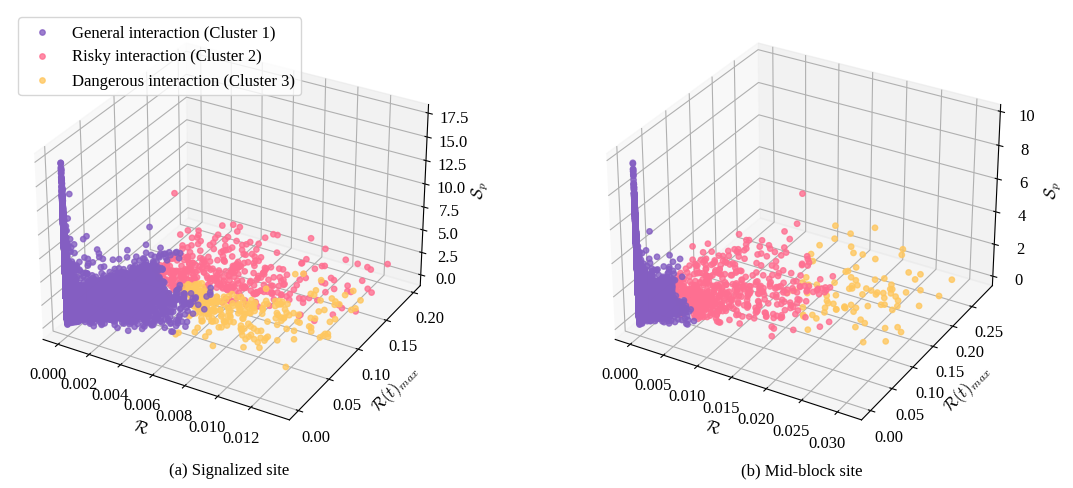

In [31]:
# 颜色固定对应 General / Risky / Dangerous
colors = ['#845ec2', '#ff6f91', '#ffc75f']

fig = plt.figure(figsize=(12, 5))

# ================= 左侧：TJ =================
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

for df, color, lab in zip(groups_TJ, colors, labels_TJ):
    d = df[['cr_revision', 'cr_max', 'spread']].replace([np.inf, -np.inf], np.nan).dropna()
    if d.empty:
        continue
    ax1.scatter(d['cr_revision'], d['cr_max'], d['spread'],
                color=color, alpha=0.8, s=15, label=lab)

ax1.set_xlabel(r'$\mathcal{R}$')
ax1.set_ylabel(r'$\mathcal{R}(t)_{max}$')
ax1.set_zlabel(r'$\mathcal{S}_{p}$')
ax1.set_title('(a) Signalized site', pad=10, y=-0.1)
ax1.legend(loc='upper left', fontsize=12)

# ================= 右侧：FC =================
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for df, color, lab in zip(groups_FC, colors, labels_FC):
    d = df[['cr_revision', 'cr_max', 'spread']].replace([np.inf, -np.inf], np.nan).dropna()
    if d.empty:
        continue
    ax2.scatter(d['cr_revision'], d['cr_max'], d['spread'],
                color=color, alpha=0.8, s=15, label=lab)

ax2.set_xlabel(r'$\mathcal{R}$')
ax2.set_ylabel(r'$\mathcal{R}(t)_{max}$')
ax2.set_zlabel(r'$\mathcal{S}_{p}$')
ax2.set_title('(b) Mid-block site', pad=10, y=-0.1)
# ax2.legend(loc='upper left', fontsize=12)  # 需要的话打开

plt.tight_layout()
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/class.pdf', dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

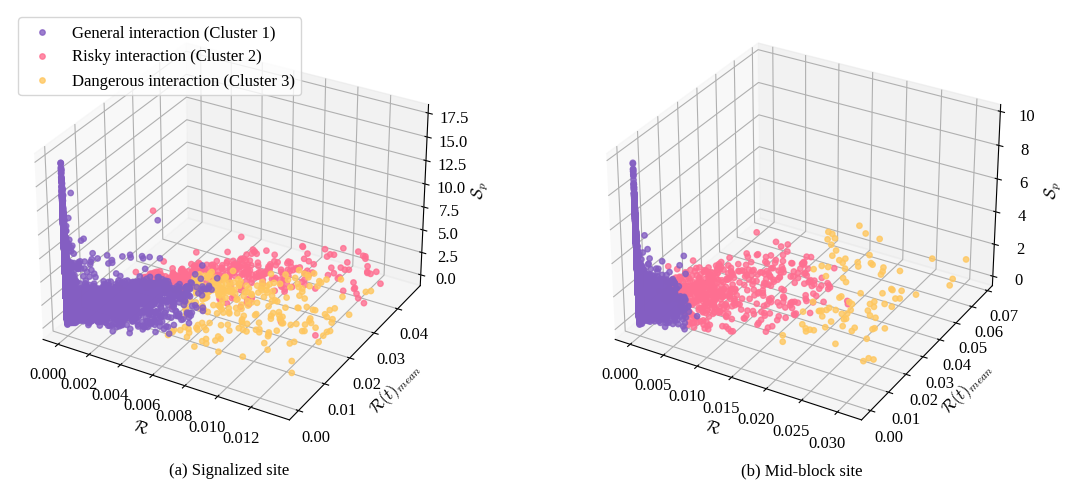

In [32]:
# 颜色固定对应 General / Risky / Dangerous
colors = ['#845ec2', '#ff6f91', '#ffc75f']

fig = plt.figure(figsize=(12, 5))

# ================= 左侧：TJ =================
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

for df, color, lab in zip(groups_TJ, colors, labels_TJ):
    d = df[['cr_revision', 'cr_mean', 'spread']].replace([np.inf, -np.inf], np.nan).dropna()
    if d.empty:
        continue
    ax1.scatter(d['cr_revision'], d['cr_mean'], d['spread'],
                color=color, alpha=0.8, s=15, label=lab)

ax1.set_xlabel(r'$\mathcal{R}$')
ax1.set_ylabel(r'$\mathcal{R}(t)_{mean}$')
ax1.set_zlabel(r'$\mathcal{S}_{p}$')
ax1.set_title('(a) Signalized site', pad=10, y=-0.1)
ax1.legend(loc='upper left', fontsize=12)

# ================= 右侧：FC =================
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for df, color, lab in zip(groups_FC, colors, labels_FC):
    d = df[['cr_revision', 'cr_mean', 'spread']].replace([np.inf, -np.inf], np.nan).dropna()
    if d.empty:
        continue
    ax2.scatter(d['cr_revision'], d['cr_mean'], d['spread'],
                color=color, alpha=0.8, s=15, label=lab)

ax2.set_xlabel(r'$\mathcal{R}$')
ax2.set_ylabel(r'$\mathcal{R}(t)_{mean}$')
ax2.set_zlabel(r'$\mathcal{S}_{p}$')
ax2.set_title('(b) Mid-block site', pad=10, y=-0.1)
# ax2.legend(loc='upper left', fontsize=12)  # 需要的话打开

plt.tight_layout()
plt.show()

/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/ipykernel_launcher.py:126: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.


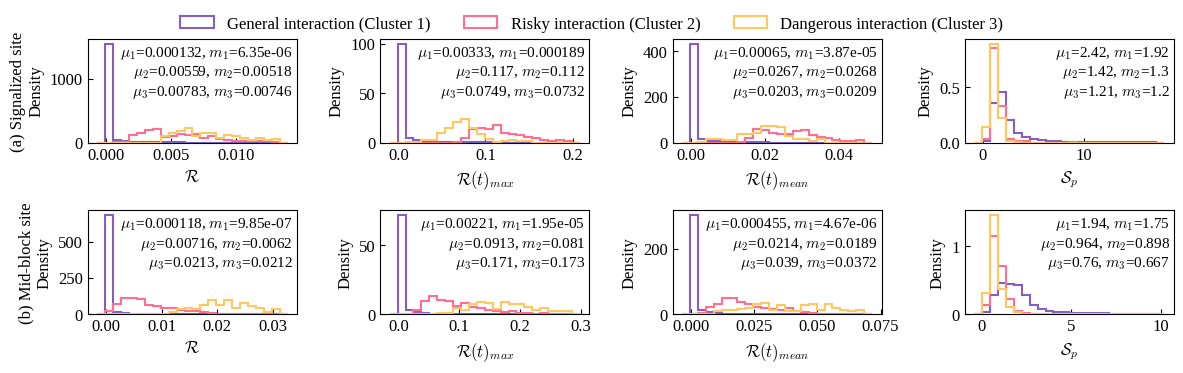

TJ means for [cluster1, cluster2, cluster3] = [0.00013236181527154835, 0.007833226780568187, 0.005588497550241662]
TJ order (General,Risky,Dangerous) indices = [0, 2, 1]
FC means for [cluster1, cluster2, cluster3] = [0.021259174664428157, 0.00011806258183088861, 0.007156410165437152]
FC order (General,Risky,Dangerous) indices = [1, 2, 0]


In [33]:
# =========================================================
# 1) 按 cr_revision 均值重新给 cluster 贴语义标签 + 统一绘图顺序
#    最大 -> Dangerous(Cluster 3); 最小 -> General(Cluster 1); 中间 -> Risky(Cluster 2)
#    返回：按 [General, Risky, Dangerous] 排序后的 (dataframes, labels)
# =========================================================
def reorder_by_cr_revision_mean(c1, c2, c3, col_ref="cr_revision"):
    groups = [c1.copy(), c2.copy(), c3.copy()]

    means = []
    for g in groups:
        s = pd.to_numeric(g[col_ref], errors="coerce").replace([np.inf, -np.inf], np.nan)
        means.append(s.mean())

    idx_max = int(np.nanargmax(means))
    idx_min = int(np.nanargmin(means))
    idx_mid = [i for i in range(3) if i not in (idx_max, idx_min)][0]

    # 画图统一顺序：General / Risky / Dangerous
    order = [idx_min, idx_mid, idx_max]
    groups_ordered = [groups[i] for i in order]

    labels_ordered = [
        "General interaction (Cluster 1)",
        "Risky interaction (Cluster 2)",
        "Dangerous interaction (Cluster 3)",
    ]
    return groups_ordered, labels_ordered, means, order


# =========================================================
# 2) 你的 metrics / colors（colors 对应 General/Risky/Dangerous）
# =========================================================
metrics = [
    ('cr_revision', 'cr_revision', r'$\mathcal{R}$'),
    ('cr_max',      'cr_max',      r'$\mathcal{R}(t)_{max}$'),
    ('cr_mean',     'cr_mean',     r'$\mathcal{R}(t)_{mean}$'),
    ('spread',      'spread',      r'$\mathcal{S}_{p}$'),
]
colors = ['#845ec2', '#ff6f91', '#ffc75f']  # General / Risky / Dangerous


# =========================================================
# 3) 对 TJ / FC 分别重新标签（按 cr_revision 均值）
# =========================================================
(TJ_groups, labels_clusters, TJ_means_raw, TJ_order) = reorder_by_cr_revision_mean(
    cluster1_TJ, cluster2_TJ, cluster3_TJ, col_ref="cr_revision"
)
(FC_groups, _labels_clusters2, FC_means_raw, FC_order) = reorder_by_cr_revision_mean(
    cluster1_FC, cluster2_FC, cluster3_FC, col_ref="cr_revision"
)
# labels_clusters 与 _labels_clusters2 内容相同（顺序固定 General/Risky/Dangerous）
# 下面绘图直接用 labels_clusters


# =========================================================
# 4) 画 2×4 直方图：每行一个场景(TJ/FC)，每列一个指标
#    每个子图：按 General/Risky/Dangerous 画三条 step-hist，并写均值/中位数
# =========================================================
fig, axes = plt.subplots(2, 4, figsize=(12, 4))
axes = axes.reshape(2, 4)

rows = [
    (TJ_groups, '(a) Signalized site'),
    (FC_groups, '(b) Mid-block site'),
]

for row_idx, (groups, row_name) in enumerate(rows):
    g1, g2, g3 = groups  # 已经是 [General, Risky, Dangerous]

    for col_idx, (col, title, xlabel) in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        data1 = pd.to_numeric(g1[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        data2 = pd.to_numeric(g2[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        data3 = pd.to_numeric(g3[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

        if all(len(d) == 0 for d in [data1, data2, data3]):
            ax.set_title(f'{title} (no data)')
            ax.set_xlabel(xlabel)
            ax.set_ylabel(f'{row_name}\nDensity' if col_idx == 0 else 'Density')
            continue

        # 统一 x 轴 bins
        all_data = pd.concat([data1, data2, data3], axis=0)
        x_min, x_max = all_data.min(), all_data.max()
        margin = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
        bins = np.linspace(x_min - margin, x_max + margin, 25)

        # 三类直方图（General/Risky/Dangerous）
        ax.hist(data1, bins=bins, density=True, histtype='step', linewidth=1.5,
                color=colors[0], label=labels_clusters[0])
        ax.hist(data2, bins=bins, density=True, histtype='step', linewidth=1.5,
                color=colors[1], label=labels_clusters[1])
        ax.hist(data3, bins=bins, density=True, histtype='step', linewidth=1.5,
                color=colors[2], label=labels_clusters[2])

        # 均值 + 中位数（按 General/Risky/Dangerous）
        m1_mean, m2_mean, m3_mean = data1.mean(), data2.mean(), data3.mean()
        m1_med,  m2_med,  m3_med  = data1.median(), data2.median(), data3.median()

        ax.text(
            0.98, 0.95,
            (
                r'$\mu_1$={:.3g}, $m_1$={:.3g}'.format(m1_mean, m1_med) + '\n' +
                r'$\mu_2$={:.3g}, $m_2$={:.3g}'.format(m2_mean, m2_med) + '\n' +
                r'$\mu_3$={:.3g}, $m_3$={:.3g}'.format(m3_mean, m3_med)
            ),
            transform=ax.transAxes,
            ha='right', va='top', fontsize=11
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(f'{row_name}\nDensity' if col_idx == 0 else 'Density')


# =========================================================
# 5) 全局图例（General/Risky/Dangerous）
# =========================================================
handles = [
    Line2D([0], [0], color=colors[0], lw=1.5),
    Line2D([0], [0], color=colors[1], lw=1.5),
    Line2D([0], [0], color=colors[2], lw=1.5),
]
fig.legend(handles, labels=labels_clusters,
           loc='upper center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, 0.95))

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/class1.pdf', dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

# （可选）如果你想打印：TJ/FC 原始 cluster(1/2/3) 各自 cr_revision 均值，方便核对
print("TJ means for [cluster1, cluster2, cluster3] =", TJ_means_raw)
print("TJ order (General,Risky,Dangerous) indices =", TJ_order)
print("FC means for [cluster1, cluster2, cluster3] =", FC_means_raw)
print("FC order (General,Risky,Dangerous) indices =", FC_order)


In [34]:
rows = [
    (TJ_groups, '(a) Signalized site'),
    (FC_groups, '(b) Mid-block site'),
]

In [35]:
len(TJ_groups)

3

/home/wangtao/anaconda3/envs/Trajectron_veh/lib/python3.7/site-packages/ipykernel_launcher.py:254: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.


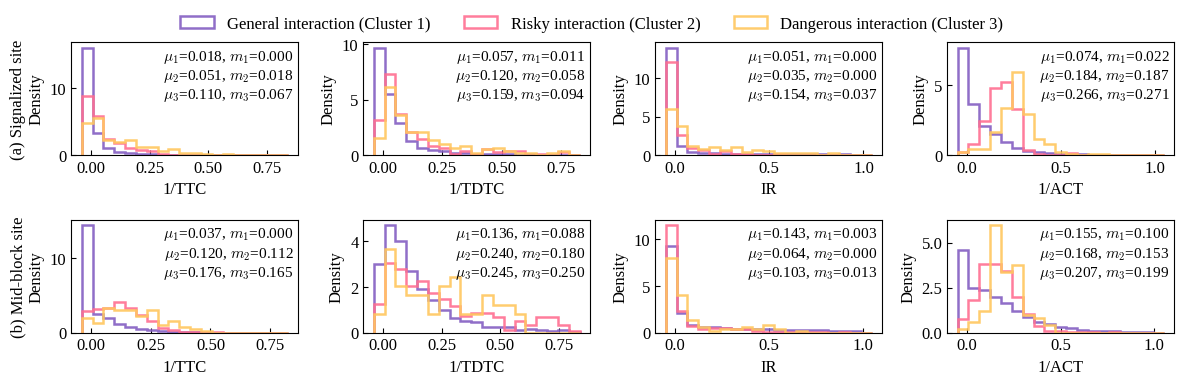

In [36]:
def clean_series(s, upper=None):
    """去掉 inf/NaN，并可选地做上界截断"""
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if upper is not None:
        s = s[s < upper]
    return s

colors = ['#845ec2', '#ff6f91', '#ffc75f']  # General / Risky / Dangerous
labels_clusters = [ 'General interaction (Cluster 1)','Risky interaction (Cluster 2)','Dangerous interaction (Cluster 3)']

# 两行：第 1 行 FC，第 2 行 TJ
rows = [
    ('(a) Signalized site', (TJ_groups[0],TJ_groups[1], TJ_groups[2])),  # 或 'FC'
    ('(b) Mid-block site', (FC_groups[0], FC_groups[1], FC_groups[2])),   # 或 'TJ'
]

fig, axes = plt.subplots(2, 4, figsize=(12, 4))
axes = axes.reshape(2, 4)

for row_idx, (row_name, (c1, c2, c3)) in enumerate(rows):
    result_with_cluster_1 = c1
    result_with_cluster_2 = c2
    result_with_cluster_3 = c3

    # ---------- (row, 0)：1/TTC ----------
    ax = axes[row_idx, 0]

    ttc_inv_1 = clean_series(1 / result_with_cluster_1['TTC'], upper=0.8)
    ttc_inv_2 = clean_series(1 / result_with_cluster_2['TTC'], upper=0.8)
    ttc_inv_3 = clean_series(1 / result_with_cluster_3['TTC'], upper=0.8)

    all_ttc_inv = pd.concat([ttc_inv_1, ttc_inv_2, ttc_inv_3])
    if len(all_ttc_inv) > 0:
        x_min, x_max = all_ttc_inv.min(), all_ttc_inv.max()
        margin = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
        bins = np.linspace(x_min - margin, x_max + margin, 20)

        for data, color, lab in zip(
            [ttc_inv_1, ttc_inv_2, ttc_inv_3],
            colors,
            labels_clusters
        ):
            if len(data) == 0:
                continue
            mu = data.mean()
            med = data.median()
            ax.hist(
                data,
                bins=bins,
                density=True,
                histtype='step',
                linewidth=1.8,
                color=color,
                alpha=0.9,
                label=f"{lab} (μ={mu:.3f}, $m$={med:.3f})"
            )

        # 在子图右上角写三类的均值/中位数
        if all(len(d) > 0 for d in [ttc_inv_1, ttc_inv_2, ttc_inv_3]):
            m1_mean, m2_mean, m3_mean = (
                ttc_inv_1.mean(), ttc_inv_2.mean(), ttc_inv_3.mean()
            )
            m1_med, m2_med, m3_med = (
                ttc_inv_1.median(), ttc_inv_2.median(), ttc_inv_3.median()
            )
            ax.text(
                0.98, 0.95,
                (
                    r'$\mu_1$={:.3f}, $m_1$={:.3f}'.format(m1_mean, m1_med) + '\n' +
                    r'$\mu_2$={:.3f}, $m_2$={:.3f}'.format(m2_mean, m2_med) + '\n' +
                    r'$\mu_3$={:.3f}, $m_3$={:.3f}'.format(m3_mean, m3_med)
                ),
                transform=ax.transAxes,
                ha='right', va='top', fontsize=11
            )

    ax.set_xlabel('1/TTC')
    ax.set_ylabel(f'{row_name}\nDensity')

    # ---------- (row, 1)：1/TDTC ----------
    ax = axes[row_idx, 1]

    tdtc_inv_1 = clean_series(1 / result_with_cluster_1['tdtc'], upper=0.8)
    tdtc_inv_2 = clean_series(1 / result_with_cluster_2['tdtc'], upper=0.8)
    tdtc_inv_3 = clean_series(1 / result_with_cluster_3['tdtc'], upper=0.8)

    all_tdtc_inv = pd.concat([tdtc_inv_1, tdtc_inv_2, tdtc_inv_3])
    if len(all_tdtc_inv) > 0:
        x_min, x_max = all_tdtc_inv.min(), all_tdtc_inv.max()
        margin = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
        bins = np.linspace(x_min - margin, x_max + margin, 20)

        for data, color, lab in zip(
            [tdtc_inv_1, tdtc_inv_2, tdtc_inv_3],
            colors,
            labels_clusters
        ):
            if len(data) == 0:
                continue
            mu = data.mean()
            med = data.median()
            ax.hist(
                data,
                bins=bins,
                density=True,
                histtype='step',
                linewidth=1.8,
                color=color,
                alpha=0.9,
                label=f"{lab} (μ={mu:.3f}, $m$={med:.3f})"
            )

        if all(len(d) > 0 for d in [tdtc_inv_1, tdtc_inv_2, tdtc_inv_3]):
            m1_mean, m2_mean, m3_mean = (
                tdtc_inv_1.mean(), tdtc_inv_2.mean(), tdtc_inv_3.mean()
            )
            m1_med, m2_med, m3_med = (
                tdtc_inv_1.median(), tdtc_inv_2.median(), tdtc_inv_3.median()
            )
            ax.text(
                0.98, 0.95,
                (
                    r'$\mu_1$={:.3f}, $m_1$={:.3f}'.format(m1_mean, m1_med) + '\n' +
                    r'$\mu_2$={:.3f}, $m_2$={:.3f}'.format(m2_mean, m2_med) + '\n' +
                    r'$\mu_3$={:.3f}, $m_3$={:.3f}'.format(m3_mean, m3_med)
                ),
                transform=ax.transAxes,
                ha='right', va='top', fontsize=11
            )

    ax.set_xlabel('1/TDTC')
    ax.set_ylabel('Density')

    # ---------- (row, 2)：VPIR ----------
    ax = axes[row_idx, 2]

    data1 = clean_series(result_with_cluster_1['VPIR'], upper=1.0)
    data2 = clean_series(result_with_cluster_2['VPIR'], upper=1.0)
    data3 = clean_series(result_with_cluster_3['VPIR'], upper=1.0)

    all_vpir = pd.concat([data1, data2, data3])
    if len(all_vpir) > 0:
        x_min, x_max = all_vpir.min(), all_vpir.max()
        margin = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
        bins = np.linspace(x_min - margin, x_max + margin, 20)

        for data, color, lab in zip(
            [data1, data2, data3],
            colors,
            labels_clusters
        ):
            if len(data) == 0:
                continue
            mu = data.mean()
            med = data.median()
            ax.hist(
                data,
                bins=bins,
                density=True,
                histtype='step',
                linewidth=1.8,
                color=color,
                alpha=0.9,
                label=f"{lab} (μ={mu:.3f}, $m$={med:.3f})"
            )

        if all(len(d) > 0 for d in [data1, data2, data3]):
            m1_mean, m2_mean, m3_mean = (
                data1.mean(), data2.mean(), data3.mean()
            )
            m1_med, m2_med, m3_med = (
                data1.median(), data2.median(), data3.median()
            )
            ax.text(
                0.98, 0.95,
                (
                    r'$\mu_1$={:.3f}, $m_1$={:.3f}'.format(m1_mean, m1_med) + '\n' +
                    r'$\mu_2$={:.3f}, $m_2$={:.3f}'.format(m2_mean, m2_med) + '\n' +
                    r'$\mu_3$={:.3f}, $m_3$={:.3f}'.format(m3_mean, m3_med)
                ),
                transform=ax.transAxes,
                ha='right', va='top', fontsize=11
            )

    ax.set_xlabel('IR')
    ax.set_ylabel('Density')

    # ---------- (row, 3)：1/ACT ----------
    ax = axes[row_idx, 3]

    data1 = clean_series(1 / result_with_cluster_1['ACT'], upper=1.0)
    data2 = clean_series(1 / result_with_cluster_2['ACT'], upper=1.0)
    data3 = clean_series(1 / result_with_cluster_3['ACT'], upper=1.0)

    all_act = pd.concat([data1, data2, data3])
    if len(all_act) > 0:
        x_min, x_max = all_act.min(), all_act.max()
        margin = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
        bins = np.linspace(x_min - margin, x_max + margin, 20)

        for data, color, lab in zip(
            [data1, data2, data3],
            colors,
            labels_clusters
        ):
            if len(data) == 0:
                continue
            mu = data.mean()
            med = data.median()
            ax.hist(
                data,
                bins=bins,
                density=True,
                histtype='step',
                linewidth=1.8,
                color=color,
                alpha=0.9,
                label=f"{lab} (μ={mu:.3f}, $m$={med:.3f})"
            )

        if all(len(d) > 0 for d in [data1, data2, data3]):
            m1_mean, m2_mean, m3_mean = (
                data1.mean(), data2.mean(), data3.mean()
            )
            m1_med, m2_med, m3_med = (
                data1.median(), data2.median(), data3.median()
            )
            ax.text(
                0.98, 0.95,
                (
                    r'$\mu_1$={:.3f}, $m_1$={:.3f}'.format(m1_mean, m1_med) + '\n' +
                    r'$\mu_2$={:.3f}, $m_2$={:.3f}'.format(m2_mean, m2_med) + '\n' +
                    r'$\mu_3$={:.3f}, $m_3$={:.3f}'.format(m3_mean, m3_med)
                ),
                transform=ax.transAxes,
                ha='right', va='top', fontsize=11
            )

    ax.set_xlabel('1/ACT')
    ax.set_ylabel('Density')

# ===== 全局图例放在上方 =====
handles = [
    Line2D([0], [0], color=colors[0], lw=1.5),
    Line2D([0], [0], color=colors[1], lw=1.5),
    Line2D([0], [0], color=colors[2], lw=1.5),
]

fig.legend(
    handles, labels=labels_clusters,
    loc='upper center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98)  # 稍微往上
)

plt.tight_layout(rect=[0, 0, 1, 0.93])  # 给上方图例留一点空间
plt.savefig('/home/wangtao/下载/Trajectron-ped-veh/Data_ana/class2.pdf', dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

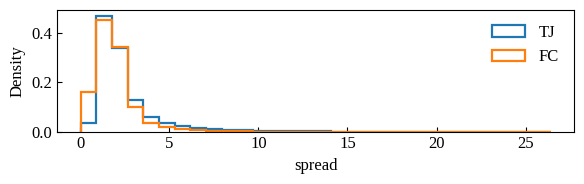

In [37]:
plt.figure(figsize=(6,2))

bins = 30
all_data = np.r_[result_font_TJ['spread'].replace([np.inf,-np.inf], np.nan).dropna().values,
                 result_font_FC['spread'].replace([np.inf,-np.inf], np.nan).dropna().values]
bin_edges = np.linspace(all_data.min(), all_data.max(), bins+1)

plt.hist(result_font_TJ['spread'].replace([np.inf,-np.inf], np.nan).dropna(),
         bins=bin_edges, density=True, histtype='step', linewidth=1.6, label='TJ')
plt.hist(result_font_FC['spread'].replace([np.inf,-np.inf], np.nan).dropna(),
         bins=bin_edges, density=True, histtype='step', linewidth=1.6, label='FC')

plt.xlabel("spread")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()